In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lammps import lammps

sys.path.insert(0, '..')
from src import *

# Set number of OpenMP threads
os.environ['OMP_NUM_THREADS'] = '10'

In [3]:
rho = 1.058
L = 10
epsilon = 1.0  # LJ energy scale
sigma = 1.0    # LJ length scale
offset = 0.05  # to avoid creating atoms on simbox face

T = 4.0
time_step = 0.0002
thermo_tau = 100 * time_step
#baro_tau = 1000 * time_step

equil_temp_steps = 10_000 
# equil_press_steps = 10_000
prod_steps = 1000
save_every = 1

In [4]:
savedir = f"../data/test/test_T{T}"
os.makedirs(savedir, exist_ok=True)
print(savedir)

../data/test/test_T4.0


In [6]:
lmp = lammps(cmdargs=['-log', os.path.join(savedir,'sim.log'), '-sf', 'omp',
                     "-screen", "none", "-nocite"])

input_script = f"""
units lj
dimension 3
boundary p p p
atom_style atomic

lattice fcc {rho} origin {offset} {offset} {offset}
region simbox block 0 {L} 0 {L} 0 {L} units lattice
create_box 1 simbox
create_atoms 1 box
mass 1 1.0
velocity all create {T} 94673 mom yes

pair_style lj/smooth 2.5 3.5
pair_coeff 1 1 1.0 1.0
pair_modify shift yes

compute temp all temp

variable time equal time
variable etot equal etotal
variable vol equal vol
variable dens equal density

compute press all pressure thermo_temp
compute press_pot all pressure NULL virial
compute born_matrix all born/matrix numdiff 1.0e-6 press_pot
compute born_matrix_nl all born/matrix/nonlinear 1.0e-6 press_pot born_matrix

# Screen and log output
thermo 1000
thermo_style custom step temp press density vol etotal
thermo_modify flush yes

# Timestep (default 0.005 for lennard-jones)
timestep {time_step}


# === EQUILIBRATION RUN =========================
fix nvt_eq all nvt temp {T} {T} {thermo_tau}
run {equil_temp_steps}
unfix nvt_eq


# === PRODUCTION RUN ==============================

# Keep constant energy
fix nve_prod all nve

# fix press_output all ave/time 1 1 {save_every} &
#    v_time c_press[*] file "{savedir}/press.dat"
# fix press_pot_output all ave/time 1 1 {save_every} &
#    v_time c_press_pot[*] file "{savedir}/press_pot.dat"
# fix born_output all ave/time 1 1 {save_every} &
#    v_time c_born_matrix[*] file "{savedir}/born.dat"
# fix born_nl_output all ave/time 1 1 {save_every} &
#    v_time c_born_matrix_nl[*] file "{savedir}/born_nl.dat"
# fix thermo_output all ave/time 1 1 {save_every} &
#    v_time c_thermo_temp v_etot v_vol v_dens file "{savedir}/thermo.dat"

# Run production
run {prod_steps}
"""

lmp.commands_string(input_script)
# lmp.command(f'write_data "{savedir}/snapshot.dump" nocoeff')

In [7]:
lmp.get_natoms()

4000

In [10]:
def cell_is_undeformed(lmp):
    cm = get_cell_matrix(lmp)
    return np.all(cm == cm[0,0] * np.eye(3))

cell_matrix = get_cell_matrix(lmp)

def probe_deformations_sym(eps):
    map_ij = voigt_to_tensor_index_map()
    deforms = np.zeros((len(map_ij), 3, 3))
    for k, (i, j) in enumerate(map_ij):
        deforms[k, i, j] += eps/2
        deforms[k, j, i] += eps/2
    return deforms, map_ij

def probe_deformations(eps):
    map_ij = voigt_to_tensor_index_map()
    deforms = np.zeros((len(map_ij), 3, 3))
    for k, (i, j) in enumerate(map_ij):
        deforms[k, i, j] = eps
    return deforms, map_ij

I = np.eye(3)

# Nonlinear Born

## as the potential energy third derivative

In [61]:
def get_pot_en_deformed(lmp, cell_matrix_deformed):
    set_cell_matrix(lmp, cell_matrix_deformed, remap=True, convert=True)
    return lmp.get_thermo("pe")

def compute_F_deform(E):
    return np.linalg.cholesky(I + 2*E, upper=True)

def compute_born_nonlin_pot_der(lmp, cell_matrix=None, eps=1e-4, undeform=True):
    E_deforms, map_ij = probe_deformations_sym(eps)
    
    lmp.command("change_box all triclinic")
    h0 = get_cell_matrix(lmp) if cell_matrix is None else cell_matrix
    NB = np.zeros((3,)*6)
    rho = lmp.get_thermo('density')
    
    for (i,j), dE1 in zip(map_ij, E_deforms):
        for (k,l), dE2 in zip(map_ij, E_deforms):
            for (m, n), dE3 in zip (map_ij, E_deforms):
                U111 = get_pot_en_deformed(lmp, compute_F_deform(- dE1 - dE2 - dE3) @ h0)
                U121 = get_pot_en_deformed(lmp, compute_F_deform(- dE1 + dE2 - dE3) @ h0)
                U211 = get_pot_en_deformed(lmp, compute_F_deform(+ dE1 - dE2 - dE3) @ h0)
                U221 = get_pot_en_deformed(lmp, compute_F_deform(+ dE1 + dE2 - dE3) @ h0)
                
                U112 = get_pot_en_deformed(lmp, compute_F_deform(- dE1 - dE2 + dE3) @ h0)
                U122 = get_pot_en_deformed(lmp, compute_F_deform(- dE1 + dE2 + dE3) @ h0)
                U212 = get_pot_en_deformed(lmp, compute_F_deform(+ dE1 - dE2 + dE3) @ h0)
                U222 = get_pot_en_deformed(lmp, compute_F_deform(+ dE1 + dE2 + dE3) @ h0)
                
                NB[i,j,k,l,m,n] = (U222 + U112 + U121 + U211 
                                   - U122 - U212 - U221 - U111) * rho / (8 * eps**3)
                if m != n:
                    NB[i,j,k,l,n,m] = NB[i,j,k,l,m,n]
            if k != l:
                NB[i, j, l, k] = NB[i, j, k, l]
        if i != j:
            NB[j, i] = NB[i, j]
    
    if undeform:
        set_cell_matrix(lmp, h0, remap=True)

    return NB

In [62]:
cell_matrix

array([[15.578469,  0.      ,  0.      ],
       [ 0.      , 15.578469,  0.      ],
       [ 0.      ,  0.      , 15.578469]])

In [63]:
NB1 = compute_born_nonlin_pot_der(lmp, cell_matrix, 1e-4)

## as the stress second derivative

In [11]:
cell_is_undeformed(lmp)

np.True_

In [12]:
def get_pk2_pot(lmp, cell_matrix_ref, F, eps=1e-7):
    set_cell_matrix(lmp, F@cell_matrix_ref, remap=True, convert=True)
    F_inv = np.linalg.inv(F)
    sigma = -lammps_array_to_matrix(lmp.numpy.extract_compute("press_pot", 0, 1))
    return np.linalg.det(F) * F_inv @ sigma @ F_inv.T

def compute_F_deform(E):
    return np.linalg.cholesky(I + 2*E, upper=True)

def compute_born_nonlin_pk2_der(lmp, cell_matrix=None, eps=1e-6, undeform=True):
    E_deforms, map_ij = probe_deformations_sym(eps)
    
    lmp.command("change_box all triclinic")
    h0 = get_cell_matrix(lmp) if cell_matrix is None else cell_matrix
    NB = np.zeros((3,)*6)
    
    for (k,l), dE1 in zip(map_ij, E_deforms):
        for (m,n), dE2 in zip(map_ij, E_deforms):
            S11 = get_pk2_pot(lmp, h0, compute_F_deform(- dE1 - dE2))
            S12 = get_pk2_pot(lmp, h0, compute_F_deform(- dE1 + dE2))
            S21 = get_pk2_pot(lmp, h0, compute_F_deform(+ dE1 - dE2))
            S22 = get_pk2_pot(lmp, h0, compute_F_deform(+ dE1 + dE2))
            NB[:,:,k,l,m,n] = (S22 + S11 - S12 - S21) / (4 * eps**2)
            if not np.allclose(NB[:,:,k,l,m,n], NB[:,:,k,l,m,n].T):
                print("nonsymmetric")
            if m != n:
                NB[:, :, k, l, n, m] = NB[:, :, k, l, m, n]
        if k != l:
            NB[:, :, l, k] = NB[:, :, k, l]
    
    if undeform:
        set_cell_matrix(lmp, h0, remap=True)

    return NB

In [13]:
NB2 = compute_born_nonlin_pk2_der(lmp, cell_matrix, 1e-5)

In [14]:
np.linalg.norm(NB1 - NB2) / np.linalg.norm(NB2)

NameError: name 'NB1' is not defined

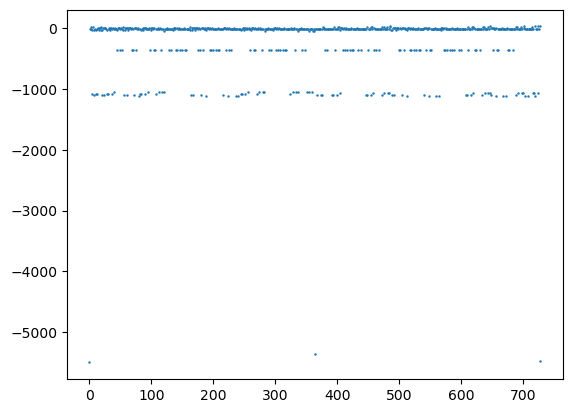

In [15]:
plt.plot(NB2.flatten(), ".", ms=1.5)

## computed in lammps

In [41]:
V = lmp.numpy.extract_variable("vol")
born_nl_raw = lmp.numpy.extract_compute("born_matrix_nl", 0, 1) / V
born_nl = born_nl_raw.reshape(21, 6).T
born_nl = lammps_array_to_matrix(born_nl)
born_nl = voigt_to_tensor(born_nl, 3)

sigma = -lammps_array_to_matrix(lmp.numpy.extract_compute('press_pot', 0, 1))
CB = voigt_to_tensor(lammps_array_to_matrix(lmp.numpy.extract_compute('born_matrix', 0, 1)) / V)

In [17]:
# test virial and born addons
tens = np.zeros_like(born_nl)
for i in range(3):
    for j in range(3):
        for k in range(3):
            for l in range(3):
                for m in range(3):
                    for n in range(3):
                        tens[i,j,k,l,m,n] = (#- (k==m) * CB[i,j,n,l] 
                                             #- (i==m) * CB[n,j,k,l] 
                                             #- (i==k) * CB[l,j,m,n]
                                             - (i==m) * (k==j) * sigma[n,l] * 2/3
                                             - (i==k) * (l==m) * sigma[j,n] * 2/3
                                             - (k==m) * (i==n) * sigma[l,j] * 2/3
                                             + 0) * 0
for i in range(3):
    for j in range(3):
        for k in range(3):
            for l in range(3):
                for m in range(3):
                    for n in range(3):
                        born_nl[i,j,k,l,m,n] += (tens[i,j,k,l,m,n] + 
                                                 tens[i,j,k,l,n,m] + 
                                                 tens[i,j,l,k,m,n] + 
                                                 tens[i,j,l,k,n,m] +
                                                 tens[j,i,k,l,m,n] + 
                                                 tens[j,i,k,l,n,m] + 
                                                 tens[j,i,l,k,m,n] + 
                                                 tens[j,i,l,k,n,m]) / 4

In [18]:
np.linalg.norm(born_nl - NB2) / np.linalg.norm(NB2)

np.float64(0.0002242402234767098)

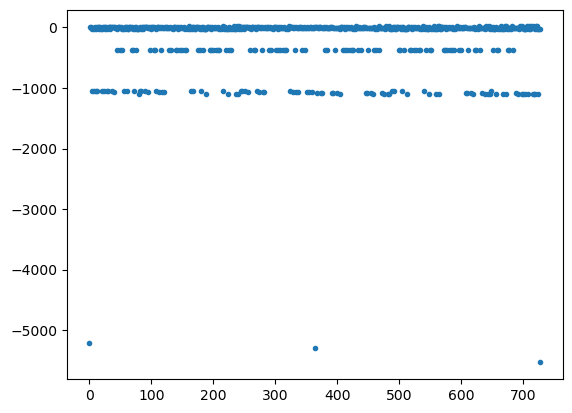

In [42]:
plt.plot(born_nl.flatten(), ".")

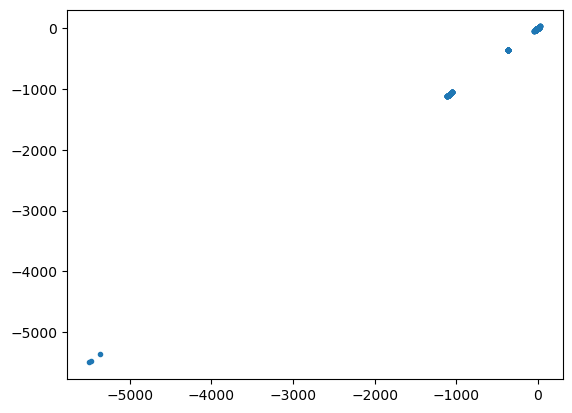

In [20]:
plt.plot(born_nl.flatten(), NB2.flatten(), ".")

In [27]:
for i in range(3):
    for j in range(i,3):
        for k in range(3):
            for l in range(k,3):
                for m in range(3):
                    for n in range(m,3):
                        if np.abs((born_nl - NB2)[i,j,k,l,m,n]) > 0.3:
                            print(f"{i},{j},{k},{l},{m},{n}")

0,0,0,1,1,1
0,0,1,1,0,1
0,1,0,0,1,1
0,1,1,1,0,0
1,1,0,0,0,1
1,1,0,1,0,0
1,1,1,1,1,2
1,1,1,2,1,1
1,2,1,1,1,1
1,2,2,2,2,2
2,2,1,2,2,2
2,2,2,2,1,2


In [29]:
born_nl[0,0,0,1,1,1]

np.float64(-20.8966731755745)

In [30]:
NB2[0,0,0,1,1,1]

np.float64(-20.588544202837507)

In [40]:
lmp.command("run 307")

# Misc: nonlinear Born as Born matrix derivative (old)

In [8]:
cell_is_undeformed(lmp)

np.True_

In [9]:
lmp.command("change_box all triclinic")

In [26]:
def get_born_raw(lmp, cell_matrix):
    set_cell_matrix(lmp, cell_matrix)
    V = lmp.numpy.extract_variable("vol")
    return lmp.numpy.extract_compute("born_matrix", 0, 1).copy() / V

def compute_born_der_raw(lmp, cell_matrix_ref=None, eps=1e-7, undeform=True):
    deforms, map_ij = probe_deformations(eps)
    
    lmp.command("change_box all triclinic")
    h0 = get_cell_matrix(lmp) if (cell_matrix_ref is None) else cell_matrix_ref
    NB = np.zeros((6,21))
    born12_raw_py = np.zeros((12,21))
    
    for idir, deform in enumerate(deforms):
        B1 = get_born_raw(lmp, (I - deform) @ h0) * np.linalg.det(I - deform)
        #born12_raw_py[2*idir] = B1 * lmp.numpy.extract_variable("vol")
        B2 = get_born_raw(lmp, (I + deform) @ h0) * np.linalg.det(I + deform)
        #born12_raw_py[2*idir + 1] = B2 * lmp.numpy.extract_variable("vol")
        NB[idir] = (B2 - B1) / (2*eps)
    
    # undeform cell
    if undeform:
        set_cell_matrix(lmp, h0, remap=True)
        lmp.command("run 0")

    return NB

In [27]:
NB_raw = compute_born_der_raw(lmp, cell_matrix_ref=cell_matrix, eps=1e-6)

In [28]:
np.linalg.norm(NB_raw.reshape(126) - born_der_raw) / np.linalg.norm(NB_raw)

np.float64(0.08309329038688992)

In [31]:
NB_raw.reshape(126) - born_der_raw

array([ 5.94241692e+01,  1.47855122e+02,  1.63522359e+02,  5.58210017e+01,
        2.15036034e+01,  3.92327866e+01,  3.92076006e+01,  2.14962446e+01,
        5.84295784e+01,  1.29559617e+01,  2.19719948e+02,  5.58445478e+01,
        8.49946725e+01, -8.33227671e+00,  5.39738378e+01,  8.08308479e+00,
        5.04349604e+01,  5.00041622e+01,  5.00451216e+01, -8.33240501e+00,
        5.84575940e+01, -3.51505726e+01, -1.63940972e+02,  7.69212376e+01,
       -3.02590887e+01, -3.06347000e+01, -1.75487814e+01, -1.75771984e+01,
       -3.06167361e+01,  2.80918129e+00, -3.06224525e+01, -1.02560312e+02,
       -3.02528036e+01, -1.07036140e+02, -6.35341520e+00, -7.19221797e+01,
       -1.08365520e+02,  6.73753032e+00, -4.01761455e+01, -4.01886997e+01,
       -6.36986151e+00,  2.82596753e+00,  1.40907691e+02,  4.52887981e+01,
        1.09803389e+02,  8.59028103e-01,  9.50750535e+01, -5.94947413e+00,
       -5.92163306e+00,  9.50800503e+01, -3.80976522e+01, -1.54968529e-01,
       -1.55234207e+01,  

In [38]:
cell_is_undeformed(lmp)

np.True_

# Compare system snapshot with the reference snapshot

In [44]:
path = '../data/equil/test_T4.0'
N = lmp.get_natoms()
pos = pd.read_csv(os.path.join(path, 'snapshot.dump'), sep=' ', header=None, 
                  names=['lable', 'type', 'x', 'y', 'z', 'dom_x', 'dom_y', 'dom_z'],
                  skiprows=15, nrows=N)
vel = pd.read_csv(os.path.join(path, 'snapshot.dump'), sep=' ', header=None, 
                  names=['lable', 'vx', 'vy', 'vz'], skiprows=18+N, nrows=N)

pos_ref = pd.read_csv(os.path.join(path, 'snapshot_ref.dump'), sep=' ', header=None, 
                     names=['lable', 'type', 'x', 'y', 'z', 'dom_x', 'dom_y', 'dom_z'],
                     skiprows=15, nrows=N)
vel_ref = pd.read_csv(os.path.join(path, 'snapshot_ref.dump'), sep=' ', header=None, 
                     names=['lable', 'vx', 'vy', 'vz'], skiprows=18+N, nrows=N)

In [45]:
np.all(vel == vel_ref) and np.all(pos == pos_ref)

np.True_